# Jaxtroseismology

In this notebook, I want to show how to fowards model a pulsating star's light curve as it rotates using the Python package jaxoplanet. We will be doing the following:

* Construct a star with a flux map over its (spherical) surface represented using spherical harmonics
* Make the spherical harmonic coefficients representing the maps vary over time (representing sinusoidal pulsations in specific modes)
* At each point in time $t$:
    * rotate the star to the correct viewing orientation
    * project the map into 2 dimensions
    * integrate the flux map over the visible surface of the star with the values for the spherical harmonic coefficients at time $t$

I will be using the methodology presented in the [$\texttt{starry}$ paper](https://iopscience.iop.org/article/10.3847/1538-3881/aae8e5) to perform the above steps analytically. I start with a vector of spherical harmonic coefficients $\mathbf{y}(t)$ representing a time-variable surface map:

$$ \mathbf{y}(t) = \mathbf{A}_y \cos(\bm{\omega}_y t)$$
where $\mathbf{A}_y$ is a vector of amplitudes of the pulsation modes and $\bm{\omega}_y$ is a vector of frequencies of the modes, one for each spherical harmonic in our representation of the stellar surface. Then, I plug this into our favorite formula from Eq. 35 of the starry paper:

$$ f = \mathbf{s}^\top \mathbf{A}\mathbf{R}\mathbf{R}\mathbf{y} $$

Using automatic vectorization in JAX, I will define this entire thing at a single point in time and have JAX vectorize our function over an entire light curve.

In [1]:
import sys
sys.path.append('../..')
import numpy as np
import jax.numpy as jnp
from jax import grad, jit, vmap

from src.jaxoplanet.experimental.starry import Surface
from jaxoplanet.experimental.starry import Ylm, show_surface
from jaxoplanet.experimental.starry.light_curves import map_light_curve

import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


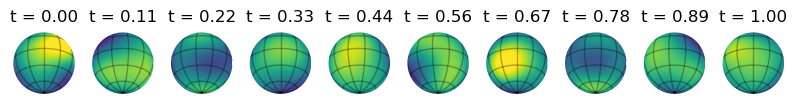

In [2]:
# fiducial parameters
np.random.seed(0)
A_y = np.hstack([1.0, np.random.rand(10) * 1e-1])
period_y = np.hstack([jnp.inf, np.random.rand(10) * 1e-1])
period = 1.0
inc = 90.0
obl = 0.0
u = np.array([0.2, 0.2])
times = jnp.linspace(0, 1.0, 10)
plt.figure(figsize=(len(times)*1, 1))
for i, t in enumerate(times):
    plt.subplot(1, 10, i+1)
    y = Ylm.from_dense(A_y*jnp.cos(2*jnp.pi*t/period_y),normalize=False)
    star = Surface(y=y, inc=inc, obl=obl, period=period, u=u)
    show_surface(star, vmax=0.4, theta=star.rotational_phase(t))
    plt.title("t = {:.2f}".format(t)) 
    


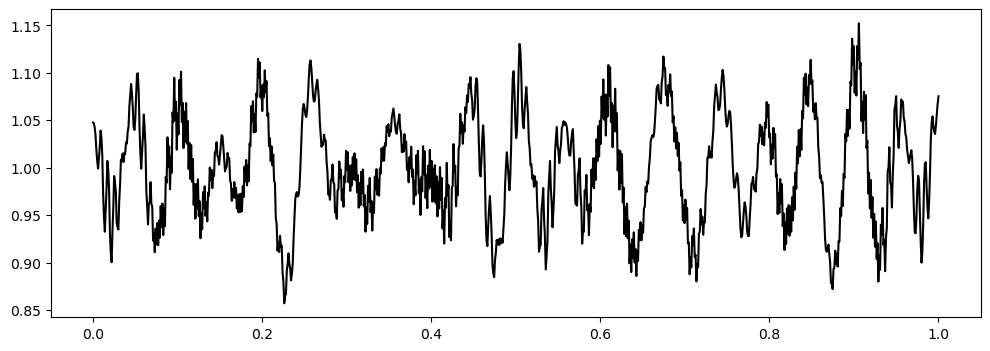

In [3]:
def compute_flux(t, A_y, period_y, inc, obl, period, u):
    y = Ylm.from_dense(A_y*jnp.cos(2*jnp.pi*t/period_y), normalize=False)
    star = Surface(y=y, inc=inc, obl=obl, period=period, u=u, normalize=False)
    return map_light_curve(star, theta=star.rotational_phase(t))

compute_flux_vec = vmap(compute_flux, in_axes=(0, None, None, None, None, None, None))
time = np.linspace(0, 1.0, 1000)
flux = compute_flux_vec(time, A_y, period_y, inc, obl, period, u)

plt.figure(figsize=(12, 4))
_ = plt.plot(time, flux, c="k")